# Handwritten Character Recognition Using CNN

## Objective
Develop a deep learning model using Convolutional Neural Networks (CNN)
to recognize handwritten characters from image data.

## Dataset
EMNIST Balanced

## Technologies
- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- OpenCV

In [1]:
!pip install -q tensorflow-datasets

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("Setup successful!")

TensorFlow: 2.20.0
Setup successful!


## 2. Dataset Loading

In [4]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Visualizing Sample Images

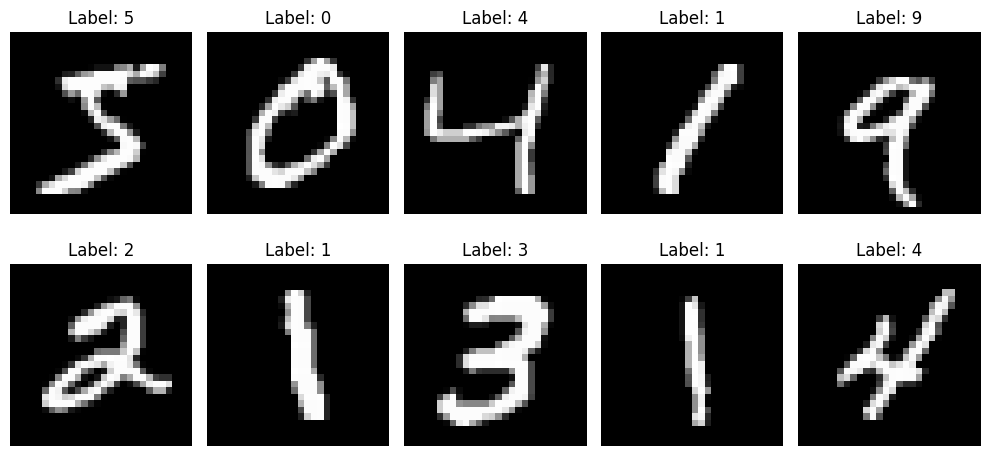

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Class Distribution and Labels

In [6]:
print("Classes:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


In [7]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


## 6. Data Preprocessing

In [8]:
# Normalize pixel values from 0-255 to 0-1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training pixel range:", X_train.min(), "to", X_train.max())
print("Testing pixel range:", X_test.min(), "to", X_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


In [9]:
# Reshape images for CNN

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


## 7. Splitting the Training Data

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Testing labels:", y_test.shape)

Training data: (54000, 28, 28, 1)
Validation data: (6000, 28, 28, 1)
Testing data: (10000, 28, 28, 1)
Training labels: (54000,)
Validation labels: (6000,)
Testing labels: (10000,)


## 8. Importing CNN Components

In [12]:
from tensorflow.keras import layers, models
model = models.Sequential([

    # Input layer
    layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Output layer - 10 digit classes
    layers.Dense(10, activation="softmax")
])

## 10. CNN Model Summary

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Compiling the CNN Model

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


## 12. Training the CNN Model

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.9073 - loss: 0.3030 - val_accuracy: 0.9753 - val_loss: 0.0810
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9713 - loss: 0.0975 - val_accuracy: 0.9818 - val_loss: 0.0606
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9782 - loss: 0.0736 - val_accuracy: 0.9855 - val_loss: 0.0527
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9825 - loss: 0.0589 - val_accuracy: 0.9873 - val_loss: 0.0474
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.9850 - loss: 0.0495 - val_accuracy: 0.9873 - val_loss: 0.0449
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9865 - loss: 0.0443 - val_accuracy: 0.9890 - val_loss: 0.0403
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9887 - loss: 0.0381 - val_accuracy: 0.9897 - val_loss: 0.0379
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9895 - loss: 0.0355 - 

## 13. Training Performance Visualization

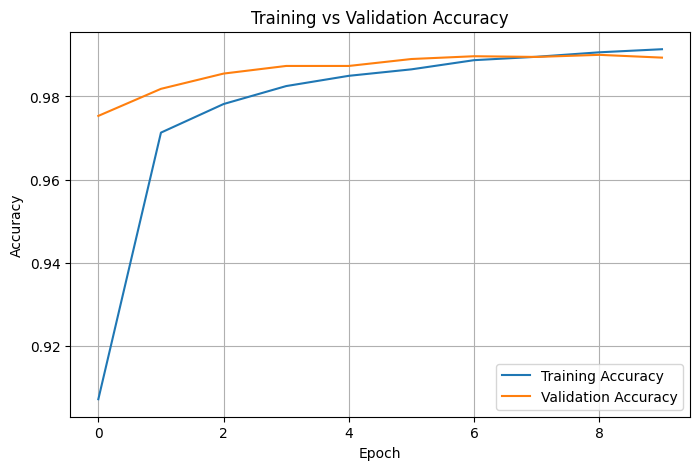

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

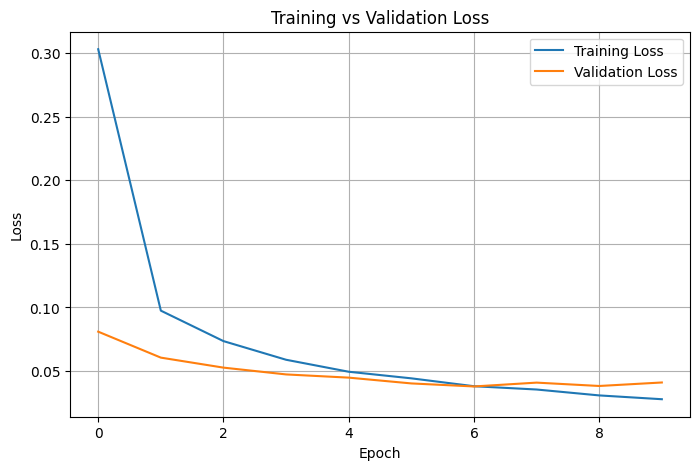

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## 14. Saving the Trained CNN Model

In [18]:
model.save("handwritten_digit_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [19]:
import os

print("Model file exists:", os.path.exists("handwritten_digit_cnn.keras"))

Model file exists: True


## 15. Evaluating the CNN on Test Data

In [20]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9920 - loss: 0.0239
Test Loss: 0.023912915959954262
Test Accuracy: 0.9919999837875366
Test Accuracy (%): 99.19999837875366


## Generate predictions for the test dataset

In [21]:


y_pred_prob = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully!")
print("Prediction shape:", y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predictions generated successfully!
Prediction shape: (10000,)


## 17. Classification Report

In [22]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 18. Confusion Matrix

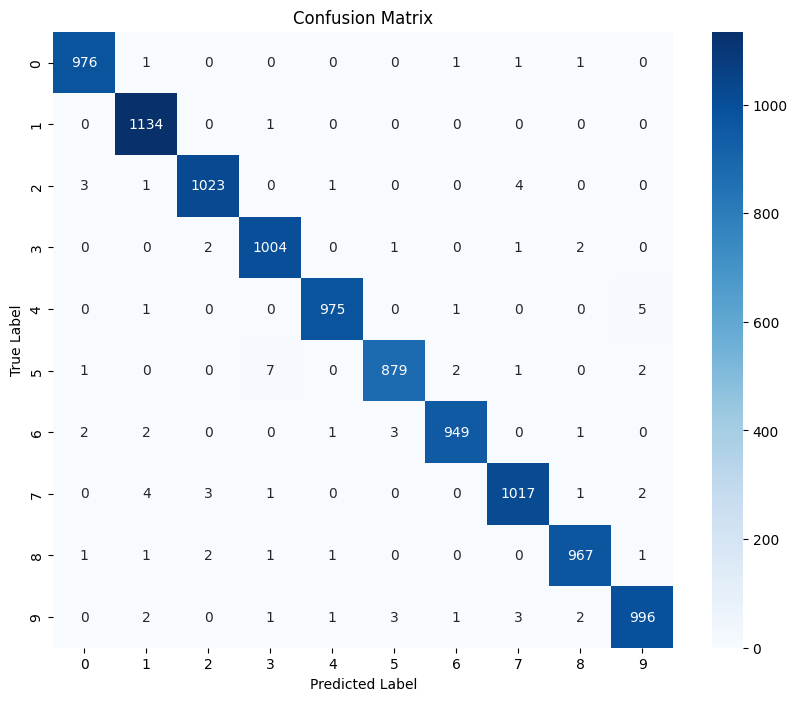

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## 19. Saving Evaluation Results

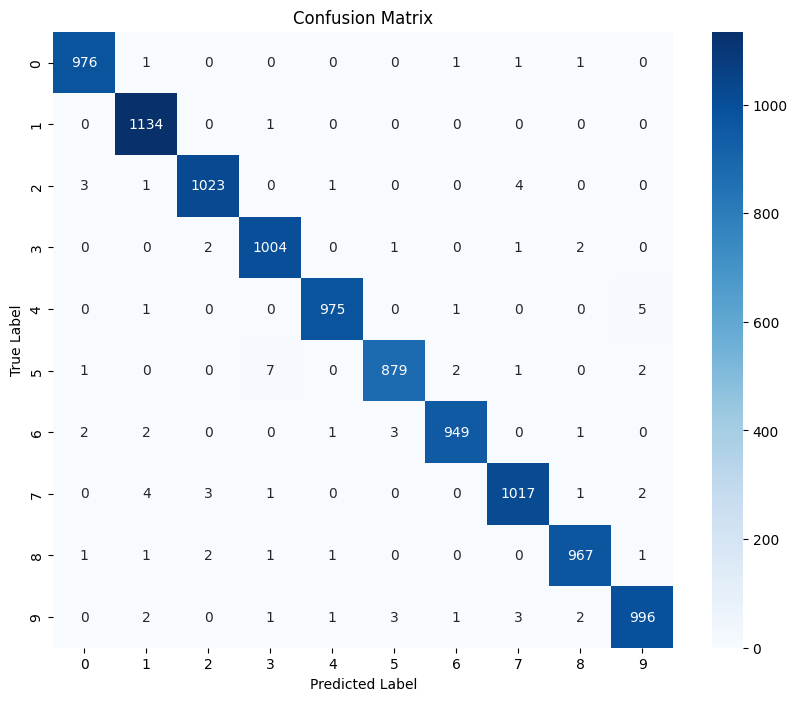

Confusion matrix saved successfully!


In [24]:
import os

# Create output folders
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

# Save confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("outputs/results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved successfully!")

## Save classification report to a text file



In [25]:
report = classification_report(y_test, y_pred)

with open("outputs/results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!


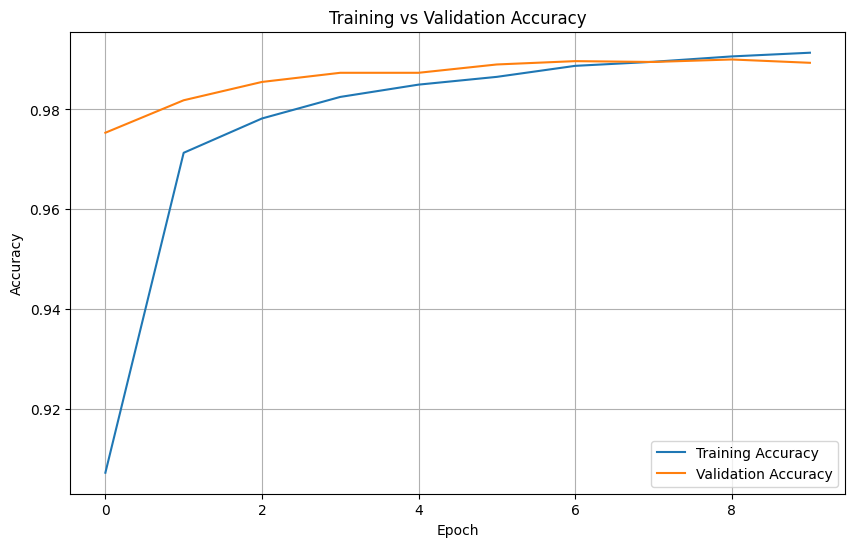

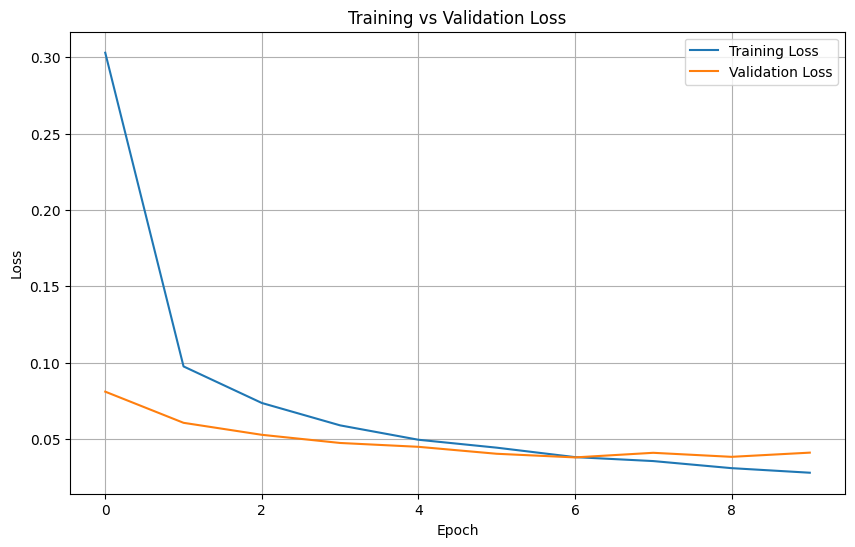

Training plots saved successfully!


In [27]:
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/plots", exist_ok=True)

# Save Training vs Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("outputs/plots/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


# Save Training vs Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("outputs/plots/loss.png", dpi=300, bbox_inches="tight")
plt.show()

print("Training plots saved successfully!")

In [28]:
import os

for root, dirs, files in os.walk("outputs"):
    for file in files:
        print(os.path.join(root, file))

outputs/plots/accuracy.png
outputs/plots/loss.png
outputs/results/classification_report.txt
outputs/results/confusion_matrix.png


In [30]:
from google.colab import files

files.download("handwritten_digit_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
from google.colab import files

files.download("outputs/plots/accuracy.png")
files.download("outputs/plots/loss.png")
files.download("outputs/results/classification_report.txt")
files.download("outputs/results/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>